In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
import json
import gzip
import shutil

import numpy as np
from scipy.optimize import linear_sum_assignment

METADATA_DIR = Path("resources/metadata")
REPORTS_DIR = Path("results/reports/qc")
FIGURES_DIR = Path("results/figures")

SAVE_RESULTS = True

# Read-loss stages available right after the `filter` stage:
# raw -> cutadapt-trimmed -> filterAndTrim-filtered.
# The merged / nochim stages live downstream in DADA2 and are out of scope here.
STAGES = ["raw", "trimmed", "filtered"]
RED_ZONE = 1_000       # reads floor we are not comfortable going below
ORANGE_ZONE = 10_000   # comfortable sequencing depth

# Group colours (Okabe-Ito, colour-blind safe)
GROUP_COLORS = {"depr": "#D55E00", "control": "#0072B2"}

# Reads QC and control down-selection

Continuation of `_eda_kyh_metadata_1.ipynb`, picking up **after the `filter` stage** of the
Snakemake pipeline (head `Snakefile` rule `filter` → `FilterAndTrim`).

## 1. Reads loss summary

Read counts are taken from the per-sample QC **reports**, *not* from
`results/reads_loss_summary.tsv` (which holds the final QC after the whole DADA2 pipeline):

- **raw** / **trimmed** — `read_counts.input` / `.output` of the cutadapt reports
- **filtered** — `reads.out` of the filterAndTrim reports

In [3]:
# Always analyse the full candidate set. Once the down-selected table has been written
# (section 3), `all_meta_full.csv` holds the original 1:many metadata, so re-running the
# notebook keeps working on the full set rather than the already-reduced one.
meta_source = METADATA_DIR / "all_meta_full.csv"
if not meta_source.exists():
    meta_source = METADATA_DIR / "all_meta.csv"
all_meta = pd.read_csv(meta_source, index_col=0)
all_meta.index.name = "ID_KYH"
print(f"loaded metadata from {meta_source} ({len(all_meta)} rows)")


def _load_json(path):
    """cutadapt reports carry a .json.gz suffix but are stored as plain JSON."""
    try:
        with open(path) as fh:
            return json.load(fh)
    except (UnicodeDecodeError, json.JSONDecodeError):
        with gzip.open(path, "rt") as fh:
            return json.load(fh)


def read_stage_counts(run):
    cutadapt = _load_json(REPORTS_DIR / "cutadapt" / f"report_{run}.json.gz")
    raw = cutadapt["read_counts"]["input"]
    trimmed = cutadapt["read_counts"]["output"]

    ft = pd.read_csv(
        REPORTS_DIR / "filterAndTrim" / f"report_{run}.tsv", sep="\t", index_col=0
    )
    reads_in, filtered = int(ft["reads.in"].iloc[0]), int(ft["reads.out"].iloc[0])
    assert reads_in == trimmed, f"{run}: cutadapt output != filterAndTrim reads.in"
    return {"raw": raw, "trimmed": trimmed, "filtered": filtered}


read_loss = pd.DataFrame(
    {run: read_stage_counts(run) for run in all_meta["Run_x"]}
).T[STAGES]
read_loss.index.name = "Run"
read_loss["filtered_to_raw"] = read_loss["filtered"] / read_loss["raw"]
read_loss["group"] = all_meta.set_index("Run_x")["depr_or_control"]

print("samples:", len(read_loss), "| by group:", read_loss["group"].value_counts().to_dict())
read_loss[STAGES + ["filtered_to_raw"]].describe()

loaded metadata from resources/metadata/all_meta.csv (263 rows)


samples: 263 | by group: {'control': 222, 'depr': 41}


,raw,trimmed,filtered,filtered_to_raw
count,263.000000,263.000000,263.000000,263.000000
mean,37754.604563,36612.692015,21419.045627,0.588833
std,25003.232860,24518.568945,18289.780980,0.295057
min,3511.000000,3317.000000,468.000000,0.020610
25%,22962.000000,22286.500000,7907.500000,0.588565
50%,34375.000000,32788.000000,18304.000000,0.732648
75%,47623.000000,46293.500000,30675.000000,0.792796
max,274039.000000,270240.000000,114631.000000,0.848669


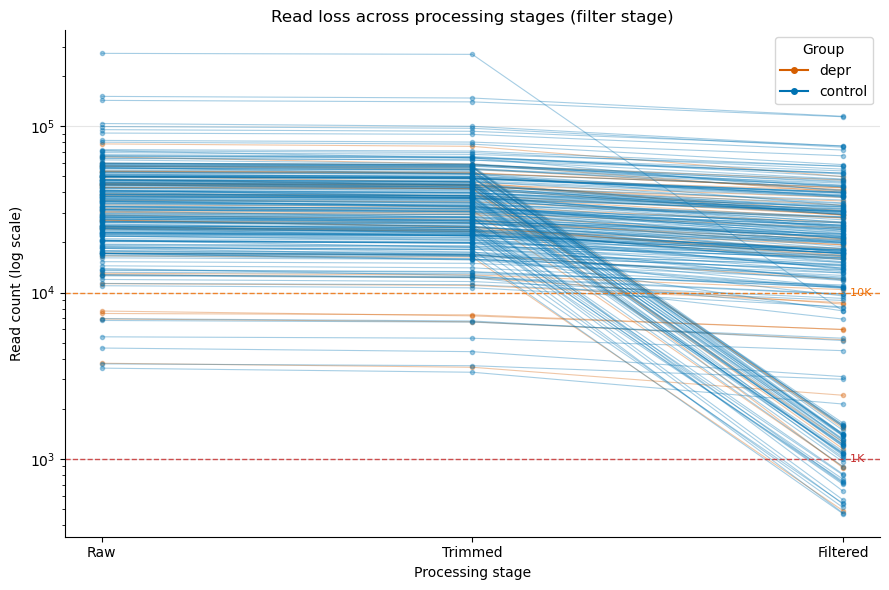

Red-zone samples (min stage < 1,000): 20 of 263
  by group: {'control': 17, 'depr': 3}


In [4]:
fig, ax = plt.subplots(figsize=(9, 6))
for _, row in read_loss.iterrows():
    ax.plot(
        range(len(STAGES)), row[STAGES].to_numpy(dtype=float),
        color=GROUP_COLORS[row["group"]],
        alpha=0.35, linewidth=0.8, marker="o", markersize=3,
    )

ax.axhline(RED_ZONE, ls="--", color="#C62828", lw=1, alpha=0.8)
ax.axhline(ORANGE_ZONE, ls="--", color="#EF6C00", lw=1, alpha=0.8)
ax.set_yscale("log")
ax.set_xticks(range(len(STAGES)))
ax.set_xticklabels([s.capitalize() for s in STAGES])
ax.set_xlabel("Processing stage")
ax.set_ylabel("Read count (log scale)")
ax.set_title("Read loss across processing stages (filter stage)")
ax.text(len(STAGES) - 1, RED_ZONE, "  1K", va="center", color="#C62828", fontsize=8)
ax.text(len(STAGES) - 1, ORANGE_ZONE, "  10K", va="center", color="#EF6C00", fontsize=8)

handles = [
    plt.Line2D([], [], color=c, marker="o", markersize=4, label=g)
    for g, c in GROUP_COLORS.items()
]
ax.legend(handles=handles, title="Group")
ax.grid(True, which="major", axis="y", color="0.9")
sns.despine(ax=ax)
fig.tight_layout()

if SAVE_RESULTS:
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIGURES_DIR / "reads_loss_eda.png", dpi=150)
plt.show()

# Red-zone samples: those dropping below the reads floor at any stage
red_zone = read_loss.index[read_loss[STAGES].min(axis=1) < RED_ZONE]
print(f"Red-zone samples (min stage < {RED_ZONE:,}): {len(red_zone)} of {len(read_loss)}")
print("  by group:", read_loss.loc[red_zone, "group"].value_counts().to_dict())

## 2. Build a 1:1 non-overlapping case-control design

Each depression sample was matched to several demographically-compatible controls
(`depr_to_control_map.csv`). We now assign **one distinct control per depression sample**
— no control is shared between cases. The assignment maximises the total reads after
filtering (an optimal bipartite matching), so the highest-quality controls are kept and,
when two cases compete for the same control, the displaced case falls back to its
next-best available control.

In [5]:
depr_to_control = pd.read_csv(METADATA_DIR / "depr_to_control_map.csv")

# reads after filtering, keyed by ID_KYH
filtered_by_id = all_meta["Run_x"].map(read_loss["filtered"])
depr_to_control["filtered"] = depr_to_control["ID_KYH_no_depr"].map(filtered_by_id)

# Optimal 1:1 non-overlapping assignment: give every depression sample a distinct
# control, maximising the total reads after filtering. Contested best controls stay
# with the strongest pairing; the displaced case falls back to its next-best available
# control. A large penalty on non-candidate pairs keeps the matching within the map.
deprs = sorted(depr_to_control["ID_KYH_depr"].unique())
ctrls = sorted(depr_to_control["ID_KYH_no_depr"].unique())
depr_ix = {d: i for i, d in enumerate(deprs)}
ctrl_ix = {c: j for j, c in enumerate(ctrls)}

FORBIDDEN = 1e12
cost = np.full((len(deprs), len(ctrls)), FORBIDDEN)
for row in depr_to_control.itertuples(index=False):
    cost[depr_ix[row.ID_KYH_depr], ctrl_ix[row.ID_KYH_no_depr]] = -row.filtered

rows, cols = linear_sum_assignment(cost)
assert (cost[rows, cols] < FORBIDDEN / 2).all(), "no feasible 1:1 matching within the candidate map"

selection = (
    pd.DataFrame({
        "ID_KYH_depr": [deprs[i] for i in rows],
        "ID_KYH_no_depr": [ctrls[j] for j in cols],
        "filtered": (-cost[rows, cols]).astype(int),
    })
    .sort_values("ID_KYH_depr")
    .reset_index(drop=True)
)

assert selection["ID_KYH_depr"].nunique() == len(deprs)
assert selection["ID_KYH_no_depr"].nunique() == len(selection), "controls overlap (design is not 1:1)"

# how many cases were bumped off their single best control by the non-overlap constraint
best_per_depr = (
    depr_to_control.sort_values("filtered", ascending=False)
    .drop_duplicates("ID_KYH_depr").set_index("ID_KYH_depr")["ID_KYH_no_depr"]
)
assigned_ctrl = selection.set_index("ID_KYH_depr")["ID_KYH_no_depr"]
downgraded = int((assigned_ctrl != best_per_depr.reindex(assigned_ctrl.index)).sum())

print("depression samples:", len(deprs))
print("unique controls (1:1, non-overlapping):", selection["ID_KYH_no_depr"].nunique())
print("cases moved off their #1 control to avoid overlap:", downgraded)
print(
    "assigned controls filtered reads: min / median / max =",
    int(selection["filtered"].min()),
    int(selection["filtered"].median()),
    int(selection["filtered"].max()),
)
if (selection["filtered"] < RED_ZONE).any():
    print(f"WARNING: {(selection['filtered'] < RED_ZONE).sum()} assigned control(s) below {RED_ZONE:,} reads")
selection.head()

depression samples: 41
unique controls (1:1, non-overlapping): 41
cases moved off their #1 control to avoid overlap: 13
assigned controls filtered reads: min / median / max = 1387 40671 114631


,ID_KYH_depr,ID_KYH_no_depr,filtered
0,1004856,1103380,52300
1,1018811,1083544,30055
2,1029459,1114629,32764
3,1031355,1190076,114631
4,1031956,1018784,74741


In [6]:
depr_ids = selection["ID_KYH_depr"].tolist()
control_ids = selection["ID_KYH_no_depr"].drop_duplicates().tolist()
keep_ids = depr_ids + control_ids  # depression rows first, then the unique controls

meta_sel = all_meta.loc[keep_ids].copy()

assert set(depr_ids).isdisjoint(control_ids)
assert len(meta_sel) == len(depr_ids) + len(control_ids)
print("rows:", len(meta_sel), "| by group:", meta_sel["depr_or_control"].value_counts().to_dict())
meta_sel[["Run_x", "depr_or_control", "batch"]].head()

rows: 82 | by group: {'depr': 41, 'control': 41}


,Run_x,depr_or_control,batch
ID_KYH,,,
1004856,SRR32393695,depr,B1
1018811,SRR32393200,depr,B2
1029459,SRR32393737,depr,B2
1031355,SRR32393342,depr,B1
1031956,SRR32393459,depr,B1


## 3. Save down-selected metadata

The current `all_meta.csv` (the full 1:many set) is backed up to `all_meta_full.csv`, and
the down-selected 1:1 table replaces `all_meta.csv`. The duplicated `Run_x` / `Run_y`
columns (a merge artefact) are collapsed into a single `Run` column, which the Snakemake
pipeline expects (`workflow/rules/common.smk` reads the table with `index_col='Run'`).

In [7]:
if SAVE_RESULTS:
    # collapse the duplicated Run_x / Run_y columns into a single `Run`
    assert (meta_sel["Run_x"] == meta_sel["Run_y"]).all()
    meta_out = meta_sel.drop(columns=["Run_x", "Run_y"]).assign(Run=meta_sel["Run_x"])

    # back up the full metadata once, then overwrite with the down-selected table
    backup = METADATA_DIR / "all_meta_full.csv"
    if backup.exists():
        print("backup already exists, kept as is ->", backup)
    else:
        shutil.copy(METADATA_DIR / "all_meta.csv", backup)
        print("backed up full metadata ->", backup)

    meta_out.to_csv(METADATA_DIR / "all_meta.csv", index_label="ID_KYH")
    print(f"wrote down-selected metadata -> {METADATA_DIR / 'all_meta.csv'} ({len(meta_out)} rows)")

backed up full metadata -> resources/metadata/all_meta_full.csv
wrote down-selected metadata -> resources/metadata/all_meta.csv (82 rows)
